# Solutions · 12 · Liquid-liquid equilibria and polymer solutions

Worked solutions to the exercises of [notebook 12](../notebooks/12_liquid_liquid_equilibria_and_polymers.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import activity, lle, unifac
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Exercise 1

Hexane-ethanol: with UNIFAC, find the temperature below which the liquid splits (the upper critical solution temperature). Scan `lle.binary` from 60 degC downwards.

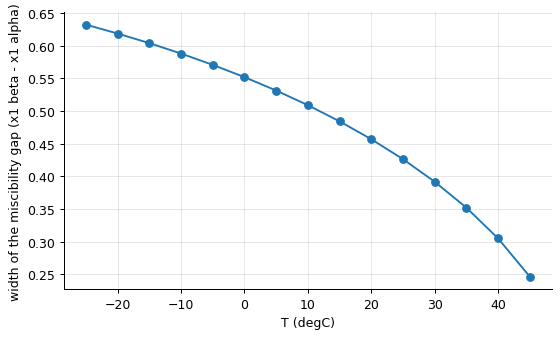

UNIFAC predicts liquid-liquid splitting below about 45 degC


In [2]:
g = unifac.gamma_function(["n-hexane", "ethanol"])
Ts = np.arange(60, -30, -5.0)
gap = []
for T_C in Ts:
    r = lle.binary(g, T_C + 273.15)
    gap.append(np.nan if r is None else r["x1_beta"] - r["x1_alpha"])
plt.plot(Ts, gap, "o-"); plt.xlabel("T (degC)"); plt.ylabel("width of the miscibility gap (x1 beta - x1 alpha)"); plt.show()
first = Ts[np.nonzero(np.isfinite(gap))[0][0]] if np.any(np.isfinite(gap)) else None
print("UNIFAC predicts liquid-liquid splitting below about", f"{first:.0f} degC" if first is not None else "no splitting down to -25 degC")

UNIFAC's large positive deviations for hexane-ethanol (limiting activity coefficients of 7 and 20, notebook 10)
imply a miscibility gap at low temperature; the predicted upper critical solution temperature is a rough
number, since UNIFAC's parameters were not fitted to liquid-liquid data, but the tendency is real -
alcohol-hydrocarbon mixtures do phase-separate in the cold, a known problem for alcohol-blended fuels.

## Exercise 2

For the illustrative polymer solution (chi = 0.20 + 90/T), plot the cloud-point (UCST) temperature against molar mass for N = 50 to 50 000 on a log axis. What does this imply for polymer fractionation by cooling?

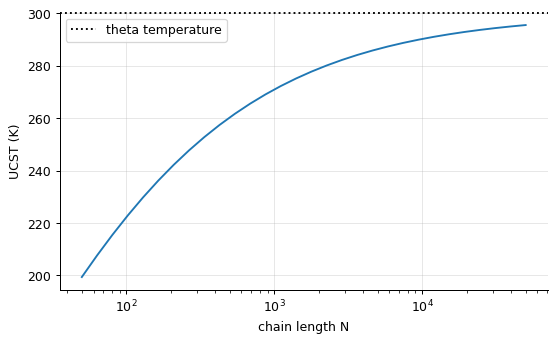

UCST: N = 50 -> 199 K, N = 50 000 -> 296 K; theta temperature 300 K


In [3]:
Ns = np.logspace(np.log10(50), np.log10(50000), 30)
T_c = [lle.ucst(0.20, 90.0, N) for N in Ns]
plt.semilogx(Ns, T_c); plt.axhline(90.0 / 0.3, color="k", ls=":", label="theta temperature"); plt.xlabel("chain length N"); plt.ylabel("UCST (K)"); plt.legend(); plt.show()
print(f"UCST: N = 50 -> {T_c[0]:.0f} K, N = 50 000 -> {T_c[-1]:.0f} K; theta temperature {90/0.3:.0f} K")

The cloud point rises steeply with chain length at first and saturates towards the theta temperature. Cooling
a polydisperse solution slowly therefore precipitates the longest chains first, then progressively shorter
ones: fractional precipitation, a classical way to narrow a polymer's molar-mass distribution.

## Exercise 3

**Implement it yourself:** derive the Flory-Huggins spinodal condition $\partial^2(\Delta G/RT)/\partial\phi^2 = 0$ by differentiating the Gibbs energy numerically, and reproduce `lle.flory_huggins_spinodal(0.7, 100)`.

In [4]:
chi, N = 0.7, 100
phi = np.linspace(0.002, 0.95, 4000)
G = lle.flory_huggins_gibbs(phi, chi, N)
d2 = np.gradient(np.gradient(G, phi), phi)
sign_change = np.nonzero(np.diff(np.sign(d2)))[0]
print("numerical spinodal:", np.round(phi[sign_change], 4), " library:", np.round(lle.flory_huggins_spinodal(chi, N), 4))

numerical spinodal: [0.0267 0.2658]  library: [0.0269 0.266 ]


The spinodal is where the curvature of the Gibbs energy changes sign; a numerical second derivative locates
both roots within the grid spacing, matching the analytical quadratic of the library.